Loaded 100 scenarios for 1072 robots.

Starting Stochastic Greedy Heuristic
Evaluating 100 Monte-Carlo Scenarios per placement...
Progress: 20 stations built, 752 robots remaining...
Progress: 40 stations built, 432 robots remaining...
Progress: 60 stations built, 112 robots remaining...

[Stochastic Greedy Finished] Stations: 67 | Expected Cost: £63829.53 | Time: 30.09s

=== Starting STOCHASTIC LOCAL SEARCH ===

[Phase 1] Executed 0 transfers. Cost: £63829.53 | Time: 0.00s
[Phase 2] Executed 0 merges. Cost: £63829.53 | Time: 0.00s
[Phase 3] Executed 15 probability-weighted shifts. Time: 0.22s

================ Final Stochastic Results ================
Expected Cost (Greedy Base): £63829.53
Expected Cost (Local Search):£63744.06

Total runtime: 30.36s


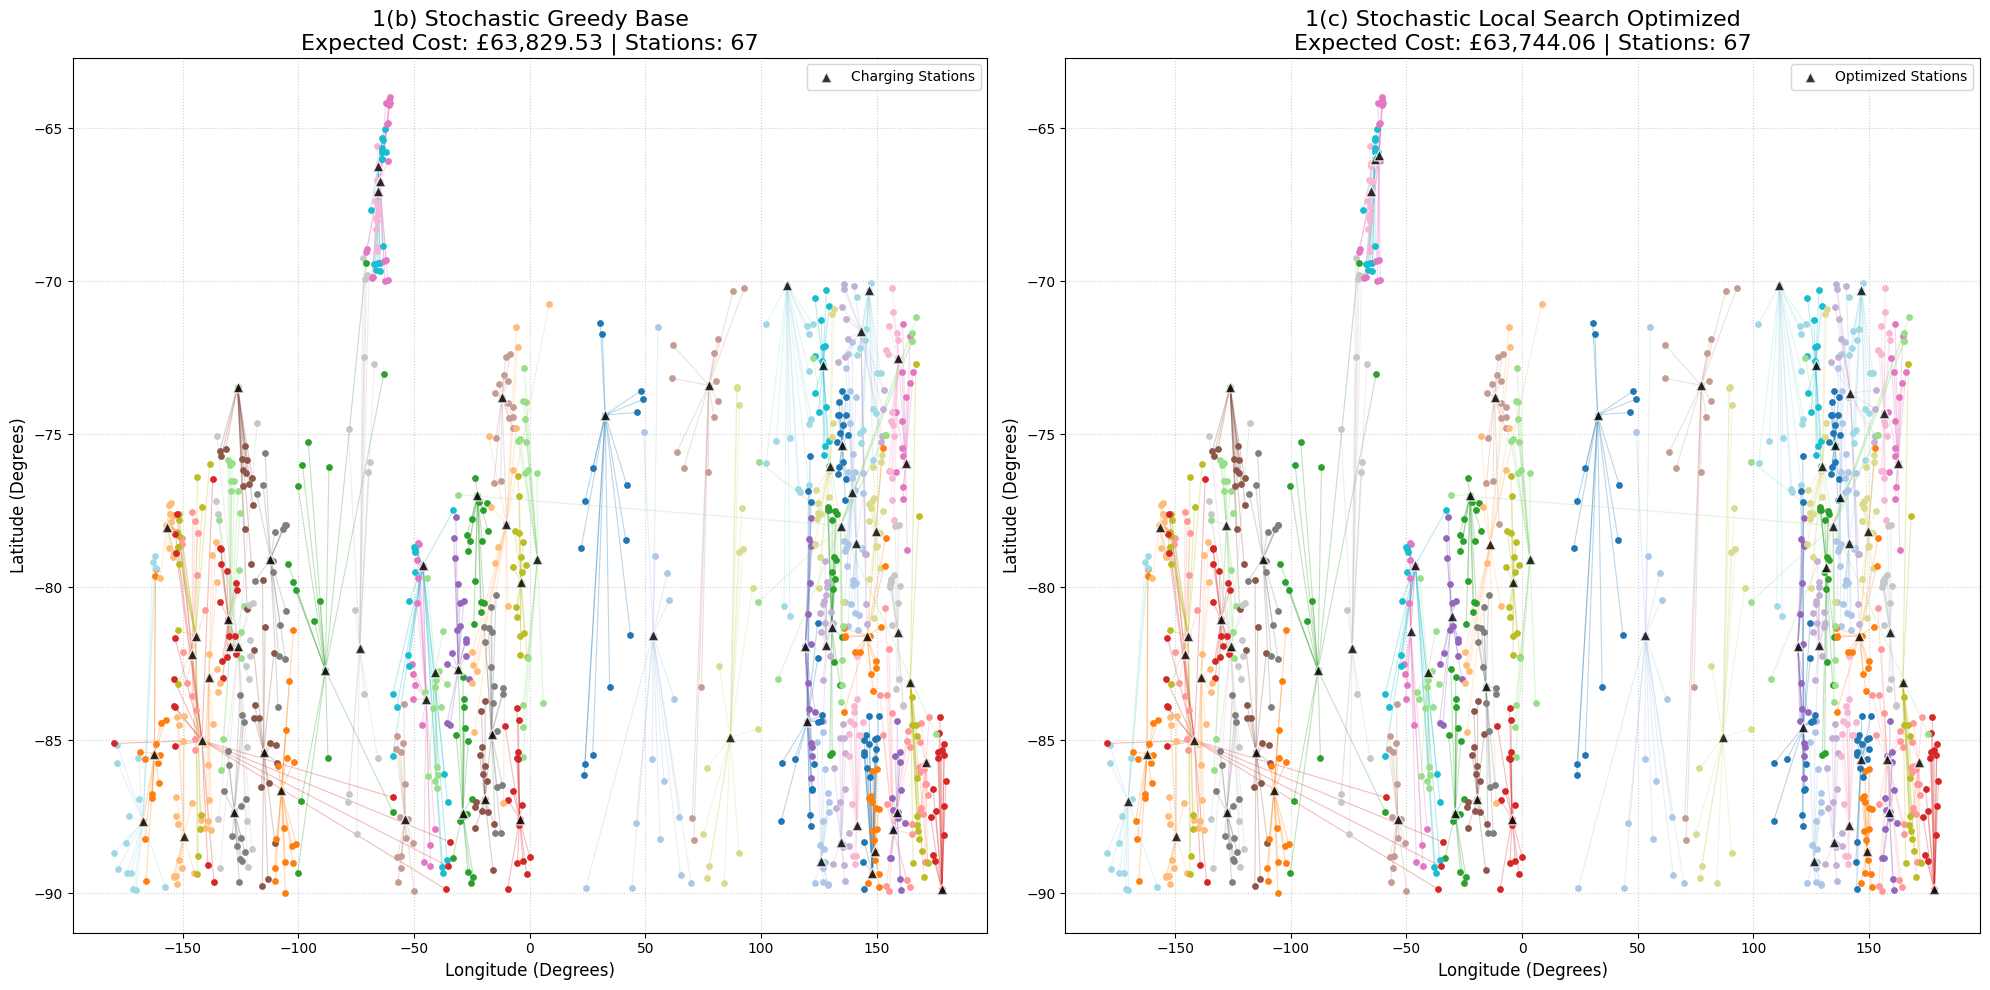

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import time

# =========================================================
# 0. Total runtime timer
# =========================================================
total_start_time = time.time()

# =========================================================
# 1. Data Loading and Stochastic Preprocessing
# =========================================================
df_loc = pd.read_csv('robot_locations.csv')
coords = df_loc[['longitude', 'latitude']].values
N = len(coords)

# Load the range data for 100 scenarios
df_scen = pd.read_csv('range_scenarios.csv')
# Remove any possible row index column (Unnamed: 0) and keep the 100 scenario columns
ranges_scen = df_scen.loc[:, df_scen.columns.str.startswith('s')].values
N_SCEN = ranges_scen.shape[1]  # 100

print(f"Loaded {N_SCEN} scenarios for {N} robots.")

# =========================================================
# 2. Distance Matrix Calculation
# =========================================================
diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

# =========================================================
# 3. Cost Parameters & Stochastic Probabilities
# =========================================================
C_b = 5000
C_m = 500
C_b_daily = C_b / 365.0
C_m_daily = C_m / 365.0
C_c = 0.42
C_h = 1000
MAX_ROBOTS = 16
R_MAX = 175 * 1.60934
R_MIN = 10 * 1.60934

# Core parameter of the stochastic model: lambda (you can adjust it as needed)
LAMBDA = 0.012

# Compute probability matrix: P = exp(-lambda^2 * (r - r_min)^2)
prob_matrix = np.exp(- (LAMBDA**2) * ((ranges_scen - R_MIN)**2))

# Generate demand matrix A_matrix via Monte Carlo sampling (1: charging needed, 0: not needed)
np.random.seed(42)
U = np.random.rand(N, N_SCEN)
A_matrix = (U <= prob_matrix).astype(int)

# =========================================================
# 4. Helper Functions for Stochastic Expected Cost
# =========================================================
def calc_expected_station_cost(station_coords, robots_list):
    """
    Compute the [average expected total cost] of a given station across 100 scenarios.
    Includes: fixed station construction cost + charger maintenance cost for peak demand
    + average electricity/flying cost + average penalty cost
    """
    if not robots_list:
        return 0

    total_fly_cost = 0.0
    total_pen_cost = 0.0
    max_chargers_needed = 0

    # Compute the physical distance from these robots to the station
    dists = np.array([calc_dist(coords[r], station_coords) for r in robots_list])

    for s in range(N_SCEN):
        active_count = 0
        fly_s = 0.0
        pen_s = 0.0

        for idx, r in enumerate(robots_list):
            if A_matrix[r, s] == 1:  # If charging is needed on this day
                if dists[idx] <= ranges_scen[r, s]:  # Within that day's flight range
                    active_count += 1
                    fly_s += (R_MAX - ranges_scen[r, s] + dists[idx]) * C_c
                else:  # Exceeds that day's flight range
                    pen_s += C_h

        total_fly_cost += fly_s
        total_pen_cost += pen_s

        # First-stage decision: charger quantity must satisfy the maximum concurrent peak over these N days
        chargers_s = math.ceil(active_count / 2)
        if chargers_s > max_chargers_needed:
            max_chargers_needed = chargers_s

    # Expected values
    expected_fly = total_fly_cost / N_SCEN
    expected_pen = total_pen_cost / N_SCEN

    return C_b_daily + max_chargers_needed * C_m_daily + expected_fly + expected_pen

def calc_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# =========================================================
# 5. Stochastic Greedy Heuristic
# =========================================================
unassigned = set(range(N))
candidates = set(range(N))

stations_built = []
total_expected_cost = 0

print(f"\n===================================================")
print(f"Starting Stochastic Greedy Heuristic")
print(f"Evaluating 100 Monte-Carlo Scenarios per placement...")
print(f"===================================================")

start_time = time.time()
iteration = 0

while unassigned:
    best_savings = 0
    best_candidate = None
    best_subset = []
    best_cost_serve = 0

    # Baseline penalty if we do not build anything for the remaining robots
    # Expected penalty for a robot = C_h * (number of scenarios it needs charging) / N_SCEN
    baseline_penalties = {i: C_h * np.sum(A_matrix[i]) / N_SCEN for i in unassigned}

    for j in candidates:
        # Sort unassigned robots by distance to j
        dists_to_j = [(i, dist_matrix[i, j]) for i in unassigned]
        dists_to_j.sort(key=lambda x: x[1])

        # Take up to MAX_ROBOTS closest robots
        subset = [i for i, d in dists_to_j[:MAX_ROBOTS]]

        baseline_cost_subset = sum(baseline_penalties[i] for i in subset)
        expected_serve_cost = calc_expected_station_cost(coords[j], subset)

        savings = baseline_cost_subset - expected_serve_cost

        if savings > best_savings:
            best_savings = savings
            best_candidate = j
            best_subset = subset
            best_cost_serve = expected_serve_cost

    if best_savings > 0:
        iteration += 1
        stations_built.append((best_candidate, best_subset))
        total_expected_cost += best_cost_serve

        candidates.remove(best_candidate)
        for robot in best_subset:
            unassigned.remove(robot)

        if iteration % 20 == 0:
            print(f"Progress: {iteration} stations built, {len(unassigned)} robots remaining...")
    else:
        break

unassigned_cost = sum(C_h * np.sum(A_matrix[i]) / N_SCEN for i in unassigned)
total_expected_cost += unassigned_cost

print(f"\n[Stochastic Greedy Finished] Stations: {len(stations_built)} | Expected Cost: £{total_expected_cost:.2f} | Time: {time.time() - start_time:.2f}s")


# =========================================================
# 6. Local Search Heuristic
# =========================================================
print("\n=======================================================")
print("=== Starting STOCHASTIC LOCAL SEARCH ===")
print("=======================================================\n")

active_stations = {}
stat_counter = 0
for stat_id, r_list in stations_built:
    active_stations[stat_counter] = {
        'coords': (coords[stat_id][0], coords[stat_id][1]),
        'robots': list(r_list)
    }
    stat_counter += 1

current_ls_cost = sum(calc_expected_station_cost(s['coords'], s['robots']) for s in active_stations.values())

# --- Phase 1: Reassign & Drop ---
start_p1 = time.time()
improvement = True
iter_p1 = 0

while improvement:
    improvement = False
    stat_ids = list(active_stations.keys())

    for s_old_id in stat_ids:
        if s_old_id not in active_stations:
            continue

        robots_in_old = list(active_stations[s_old_id]['robots'])
        for robot in robots_in_old:
            best_move_savings = 0.001
            best_s_new_id = None

            for s_new_id in stat_ids:
                if s_new_id == s_old_id or s_new_id not in active_stations:
                    continue
                if len(active_stations[s_new_id]['robots']) >= MAX_ROBOTS:
                    continue

                old_cost_A = calc_expected_station_cost(active_stations[s_old_id]['coords'], active_stations[s_old_id]['robots'])
                old_cost_B = calc_expected_station_cost(active_stations[s_new_id]['coords'], active_stations[s_new_id]['robots'])

                temp_old_robots = [r for r in active_stations[s_old_id]['robots'] if r != robot]
                temp_new_robots = active_stations[s_new_id]['robots'] + [robot]

                new_cost_A = calc_expected_station_cost(active_stations[s_old_id]['coords'], temp_old_robots)
                new_cost_B = calc_expected_station_cost(active_stations[s_new_id]['coords'], temp_new_robots)

                savings = (old_cost_A + old_cost_B) - (new_cost_A + new_cost_B)

                if savings > best_move_savings:
                    best_move_savings = savings
                    best_s_new_id = s_new_id

            if best_s_new_id is not None:
                active_stations[s_old_id]['robots'].remove(robot)
                active_stations[best_s_new_id]['robots'].append(robot)
                current_ls_cost -= best_move_savings
                improvement = True
                iter_p1 += 1

        if len(active_stations[s_old_id]['robots']) == 0:
            del active_stations[s_old_id]

print(f"[Phase 1] Executed {iter_p1} transfers. Cost: £{current_ls_cost:.2f} | Time: {time.time()-start_p1:.2f}s")

# --- Phase 2: Merge & Shift ---
start_p2 = time.time()
improvement = True
iter_p2 = 0
K_MAX = 3

while improvement:
    improvement = False
    stat_ids = list(active_stations.keys())

    for i in range(len(stat_ids)):
        if stat_ids[i] not in active_stations:
            continue
        stat_A_id = stat_ids[i]

        neighbors = []
        for j in range(len(stat_ids)):
            if i != j and stat_ids[j] in active_stations:
                d = calc_dist(active_stations[stat_A_id]['coords'], active_stations[stat_ids[j]]['coords'])
                neighbors.append((d, stat_ids[j]))

        neighbors.sort()
        closest_neighbors = [nid for d, nid in neighbors[:K_MAX-1]]

        merge_candidates = []
        for k in range(2, K_MAX + 1):
            if len(closest_neighbors) >= k - 1:
                merge_candidates.append([stat_A_id] + closest_neighbors[:k-1])

        best_merge_savings = 0.001
        best_merge_plan = None
        best_new_coords = None

        for cand_group in merge_candidates:
            combined_robots = []
            for s_id in cand_group:
                combined_robots.extend(active_stations[s_id]['robots'])

            if len(combined_robots) > MAX_ROBOTS:
                continue

            robot_coords = coords[combined_robots]
            new_coords = (np.mean(robot_coords[:, 0]), np.mean(robot_coords[:, 1]))

            old_cost = sum(calc_expected_station_cost(active_stations[s]['coords'], active_stations[s]['robots']) for s in cand_group)
            new_cost = calc_expected_station_cost(new_coords, combined_robots)

            savings = old_cost - new_cost
            if savings > best_merge_savings:
                best_merge_savings = savings
                best_merge_plan = (cand_group, combined_robots)
                best_new_coords = new_coords

        if best_merge_plan is not None:
            cand_group, combined_robots = best_merge_plan
            for s_id in cand_group:
                del active_stations[s_id]

            new_stat_id = stat_counter
            stat_counter += 1
            active_stations[new_stat_id] = {'coords': best_new_coords, 'robots': combined_robots}
            current_ls_cost -= best_merge_savings
            improvement = True
            iter_p2 += 1
            break

print(f"[Phase 2] Executed {iter_p2} merges. Cost: £{current_ls_cost:.2f} | Time: {time.time()-start_p2:.2f}s")

# --- Phase 3: Weiszfeld Shift ---
start_p3 = time.time()
iter_p3 = 0

for s_id, stat_data in active_stations.items():
    robots = stat_data['robots']
    if len(robots) <= 1:
        continue

    current_coords = np.array(stat_data['coords'])
    robot_coords = coords[robots]

    best_cost = calc_expected_station_cost(current_coords, robots)
    best_coords = current_coords
    test_coords = current_coords.copy()

    for _ in range(30):
        # Add probability weights (expected active scenarios per robot)
        W = np.zeros(len(robots))
        for idx, r in enumerate(robots):
            d = calc_dist(coords[r], test_coords)
            can_reach = d <= ranges_scen[r]  # Array of 100 bools
            actually_served = (A_matrix[r] == 1) & can_reach
            W[idx] = np.sum(actually_served) / N_SCEN  # Utilization rate

        diff = robot_coords - test_coords
        dists = np.sqrt(np.sum(diff**2, axis=1))
        dists[dists < 1e-9] = 1e-9

        step_weights = W / dists
        if np.sum(step_weights) == 0:
            break

        new_x = np.sum(step_weights * robot_coords[:, 0]) / np.sum(step_weights)
        new_y = np.sum(step_weights * robot_coords[:, 1]) / np.sum(step_weights)
        new_coords = np.array([new_x, new_y])

        if np.sqrt(np.sum((new_coords - test_coords)**2)) < 1e-6:
            break

        new_cost = calc_expected_station_cost(new_coords, robots)
        if new_cost < best_cost:
            best_cost = new_cost
            best_coords = new_coords
            test_coords = new_coords
        else:
            break

    savings = calc_expected_station_cost(stat_data['coords'], robots) - best_cost
    if savings > 1e-4:
        active_stations[s_id]['coords'] = (best_coords[0], best_coords[1])
        current_ls_cost -= savings
        iter_p3 += 1

print(f"[Phase 3] Executed {iter_p3} probability-weighted shifts. Time: {time.time()-start_p3:.2f}s")

# =========================================================
# Summary
# =========================================================
final_total_cost = current_ls_cost + unassigned_cost
print(f"\n================ Final Stochastic Results ================")
print(f"Expected Cost (Greedy Base): £{total_expected_cost:.2f}")
print(f"Expected Cost (Local Search):£{final_total_cost:.2f}")
print("==========================================================\n")

# Print total runtime excluding plotting
total_runtime = time.time() - total_start_time
print(f"Total runtime: {total_runtime:.2f}s")

# =========================================================
# 7. Global Visualization: Greedy vs Local Search
# =========================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# ---------------------------------------------------------
# Plot 1: 1(b) Stochastic Greedy Base
# ---------------------------------------------------------
unassigned_list = list(unassigned)
if unassigned_list:
    ax1.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1],
                c='red', marker='x', s=40, linewidth=1.5, label='Unassigned (Penalty)', zorder=3)

greedy_station_x, greedy_station_y = [], []
cmap = plt.get_cmap('tab20')

for idx, (stat_id, robots) in enumerate(stations_built):
    color = cmap(idx % 20)
    sx, sy = coords[stat_id]
    greedy_station_x.append(sx)
    greedy_station_y.append(sy)

    for r_id in robots:
        rx, ry = coords[r_id]
        ax1.plot([rx, sx], [ry, sy], c=color, alpha=0.3, linewidth=0.8, zorder=1)
        ax1.scatter(rx, ry, c=[color], s=15, zorder=2)

if greedy_station_x:
    ax1.scatter(greedy_station_x, greedy_station_y, c='black', marker='^', s=60, alpha=0.8, edgecolors='white', zorder=4, label='Charging Stations')

ax1.set_title(f'1(b) Stochastic Greedy Base\nExpected Cost: £{total_expected_cost:,.2f} | Stations: {len(stations_built)}', fontsize=16)
ax1.set_xlabel('Longitude (Degrees)', fontsize=12)
ax1.set_ylabel('Latitude (Degrees)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

# Legend handling (avoid duplicates)
handles1, labels1 = ax1.get_legend_handles_labels()
by_label1 = dict(zip(labels1, handles1))
if by_label1:
    ax1.legend(by_label1.values(), by_label1.keys(), loc='best', fontsize=10)

# ---------------------------------------------------------
# Plot 2: 1(c) Stochastic Local Search Optimized
# ---------------------------------------------------------
if unassigned_list:
    ax2.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1],
                c='red', marker='x', s=40, linewidth=1.5, label='Unassigned (Penalty)', zorder=3)

ls_station_x, ls_station_y = [], []

for idx, stat_data in enumerate(active_stations.values()):
    color = cmap(idx % 20)
    sx, sy = stat_data['coords']
    ls_station_x.append(sx)
    ls_station_y.append(sy)

    for r_id in stat_data['robots']:
        rx, ry = coords[r_id]
        ax2.plot([rx, sx], [ry, sy], c=color, alpha=0.3, linewidth=0.8, zorder=1)
        ax2.scatter(rx, ry, c=[color], s=15, zorder=2)

if ls_station_x:
    ax2.scatter(ls_station_x, ls_station_y, c='black', marker='^', s=60, alpha=0.8, edgecolors='white', zorder=4, label='Optimized Stations')

ax2.set_title(f'1(c) Stochastic Local Search Optimized\nExpected Cost: £{final_total_cost:,.2f} | Stations: {len(active_stations)}', fontsize=16)
ax2.set_xlabel('Longitude (Degrees)', fontsize=12)
ax2.set_ylabel('Latitude (Degrees)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# Legend handling (avoid duplicates)
handles2, labels2 = ax2.get_legend_handles_labels()
by_label2 = dict(zip(labels2, handles2))
if by_label2:
    ax2.legend(by_label2.values(), by_label2.keys(), loc='best', fontsize=10)

plt.tight_layout()
plt.show()